In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from fismi import ismiReplication as fismi
from fismi import utils
from fismi import figures
from fismi import maths
import statsmodels.api as sm
import seaborn as sns

In [2]:
# Import data
niv = '2'

# Unchained other items 
dfICP = pd.read_parquet(f"input/USItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/USnormedWeightsLvl{niv}.parquet") 

# We compute headline inflation (PCE variation over a 12-month period)
headline = (np.log(dfICP["Personal consumption expenditures"]).diff(12)[1:]*100)  # Inflation headline annuelle glissante

# We compute monthly inflation rates
dfInflation = (np.log(dfICP).diff(1)[1:]*100)
InflTot = dfInflation["Personal consumption expenditures"].to_frame()           # To replicate Figure A1
dfInflation = dfInflation.drop("Personal consumption expenditures",axis=1)

# Drop series
if niv=='4':
    colToDrop = ["Internet access (72)","Video and audio streaming and rental"]
    dfInflation = dfInflation.loc[:, ~dfInflation.columns.isin(colToDrop)]
    dfW = dfW.loc[:, ~dfW.columns.isin(colToDrop)]

In [3]:
# Initial parameters
pi = InflTot.iloc[:, 0].values

F = 0.9
mu = pi.mean()            
rho_bar = 0.5
D = pi.std()              
B = 0.2

X0 = [mu, rho_bar, F, D, B]
M = 1
mu, rho_bar, F, H, Q = maths.get_parameters(X0, M)

print(f"Average monthly inflation : {mu}")
print(f"Long-run persistence : {rho_bar}")
print(f"AR(1) state coefficient (inertial persistence) : {F}")
print(f"Measurement error variance : {H}")
print(f"Variance of the state innovations : {Q}")

Average monthly inflation : 0.26682605543648336
Long-run persistence : 0.5
AR(1) state coefficient (inertial persistence) : 0.9
Measurement error variance : 0.05984368621348468
Variance of the state innovations : 0.04000000000000001


In [4]:
# Optimise...
res = maths.optNegLogLike(X0, pi)
res

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -301.7708705011372
        x: [ 1.250e-01  3.879e-01  9.894e-01  1.620e-01  3.318e-02]
      nit: 26
      jac: [-5.684e-06  0.000e+00  1.137e-05 -6.253e-05 -5.684e-06]
     nfev: 258
     njev: 43
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>

In [5]:
# Get parameters...
print("Optimisation successful...")
mu, rho_bar, F, H, Q = maths.get_parameters(res.x, M)
print(f"Average monthly inflation : {mu}")
print(f"Long-run persistence : {rho_bar}")
print(f"AR(1) state coefficient (inertial persistence) : {F}")
print(f"Measurement error variance : {H}")
print(f"Variance of the state innovations : {Q}")

Optimisation successful...
Average monthly inflation : 0.12495305996016669
Long-run persistence : 0.38791236654944766
AR(1) state coefficient (inertial persistence) : 0.9893801086602875
Measurement error variance : 0.02623545603328028
Variance of the state innovations : 0.0011007147950336164


In [6]:
# Filter...
results = maths.kalman_filter_inflation(X0, pi, return_loglik=False)

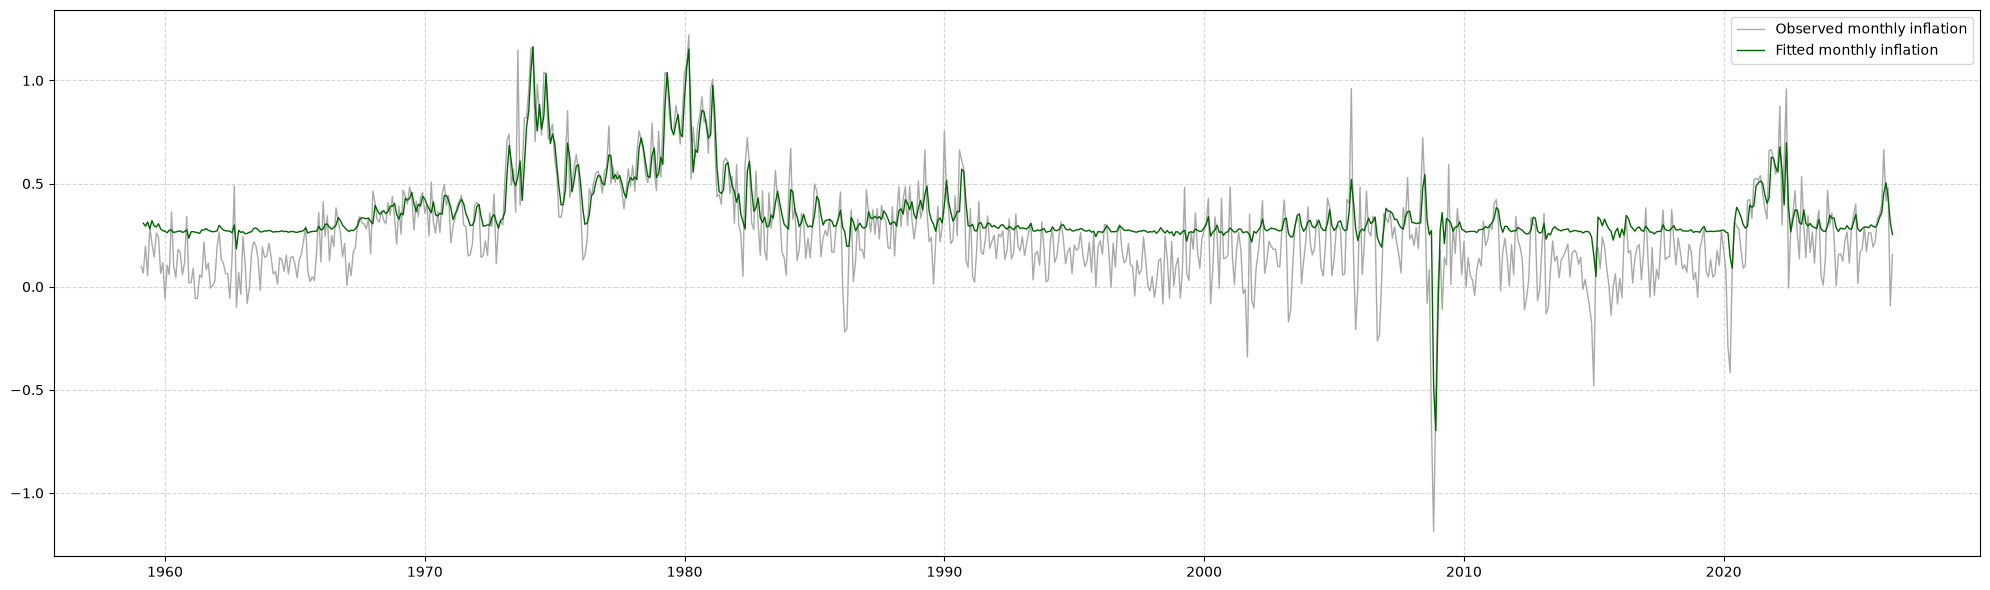

In [8]:
# Inflation versus predicted
fitted = results["InflationFiltered"]
pi = results["Inflation"]
xAxis = InflTot.index

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(
    xAxis,
    pi,
    label=f"Observed monthly inflation",
    color="darkgrey",
    linewidth=1,
)

ax.grid(True, linestyle="--", alpha=0.5)

ax.plot(
    xAxis,
    fitted,
    label=f"Fitted monthly inflation",
    color="darkgreen",
    linewidth=1,
)

plt.legend()
plt.tight_layout()
plt.show()
